# Theory

What if I were to combine the various player vectors somehow to come up with a representation of a team? Maybe I can do this by:
1. Adding player vectors
2. Adding player vectors then get average
3. Self weighting average of players in team

I then take those 2 team representations and get the difference between them. Maybe I can do this by:
1. Difference of team vectors

I then run this difference through the model, since in my mind the difference between the teams should decide the score line

## Strategies

- I'll call the method of adding players the difference of team the **Difference strategy**
- I'll call the method of adding players, getting average then difference of teams the **Average Difference Strategy**. Graphically adding then getting the average gives a vector that seems to be around middle of other vectors, which could be a good approximation of the team
- I'll call the method of self weighting averages then getting difference of teams the **Self Weighting average**. I want to give priority to larger values in the average, with the intuition that if a team has a really good player their effect should be pronounced.

In [34]:
# Imports
import numpy as np
import numpy.typing as npt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import math
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=121)

# Importing data

Importing data that will be used

In [35]:
# Combine players in training set
X = np.load("data/duplicate_players_batch_6_2026-06-01 18:30:48.366255.npy")
Y = np.load("data/duplicate_results_batch_6_2026-06-01 18:30:48.366274.npy")

# Trim target variable
Y_trimmed = np.squeeze(Y, axis=-1)

# Difference strategy
Sum_first_half = np.sum(X[:, :11, :], axis=1)
Sum_second_half = np.sum(X[:, 11:, :], axis=1)
X_Difference = Sum_first_half - Sum_second_half

# Average Difference strategy
Mean_first_half = np.mean(X[:, :11, :], axis=1)
Mean_second_half = np.mean(X[:, 11:, :], axis=1)
X_Average_Difference = Mean_first_half - Mean_second_half

# Self weighting average strategy
weights_team_1 = X[:, :11, :]
numerator_team_1 = np.sum(X[:, :11, :] * weights_team_1, axis=1)
denominator_team_1 = np.sum(weights_team_1, axis=1)
safe_denominator_team_1 = np.where(denominator_team_1 == 0, 1, denominator_team_1)
Weighted_first_team = numerator_team_1 / safe_denominator_team_1

weights_team_2 = X[:, 11:, :]
numerator_team_2 = np.sum(X[:, 11:, :] * weights_team_2, axis=1)
denominator_team_2 = np.sum(weights_team_2, axis=1)
safe_denominator_team_2 = np.where(denominator_team_2 == 0, 1, denominator_team_2)
Weighted_second_team = numerator_team_2 / safe_denominator_team_2

X_Self_Weighted = Weighted_first_team - Weighted_second_team


In [36]:
# Split data into train, dev and test sets
X_train, X_mid, Y_train, Y_mid = train_test_split(X_Difference, Y_trimmed, test_size=0.14, random_state=121)
X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=121)
print(X_train.shape, X_cv.shape, X_test.shape)
print(Y_train.shape, Y_cv.shape, Y_test.shape)

# X_train, X_mid, Y_train, Y_mid = train_test_split(X_Average_Difference, Y_trimmed, test_size=0.14, random_state=121)
# X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=121)
# print(X_train.shape, X_cv.shape, X_test.shape)
# print(Y_train.shape, Y_cv.shape, Y_test.shape)

# X_train, X_mid, Y_train, Y_mid = train_test_split(X_Self_Weighted, Y_trimmed, test_size=0.14, random_state=121)
# X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=121)
# print(X_train.shape, X_cv.shape, X_test.shape)
# print(Y_train.shape, Y_cv.shape, Y_test.shape)


(1203, 9) (98, 9) (99, 9)
(1203, 121) (98, 121) (99, 121)


In [37]:
# Transpose target outputs and features to match what my network is working with
X_train = X_train.T
X_cv = X_cv.T
X_test = X_test.T
Y_train = Y_train.T
Y_cv = Y_cv.T
Y_test = Y_test.T

print(X_train.shape, Y_train.shape)
print(X_cv.shape, Y_cv.shape)
print(X_test.shape, Y_test.shape)

(9, 1203) (121, 1203)
(9, 98) (121, 98)
(9, 99) (121, 99)


In [38]:
# Normalize data
mean = np.mean(X_train, axis=(1,0), keepdims=True)
std = np.std(X_train, axis=(1,0), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_train_scaled = (X_train - mean) / std
X_cv_scaled = (X_cv - mean) / std
X_test_scaled = (X_test - mean) / std
print(X_train_scaled.shape)
print(X_cv_scaled.shape)
print(X_test_scaled.shape)

(9, 1203)
(9, 98)
(9, 99)


# Implementing Model

Implementing forward prop, cost functions, back prop and confirming backprop implementation

In [39]:
# Hyperparameters
beta_m = 0.9
beta_r = 0.999
alpha = 0.01
batch_size = 256
lambd = 0.1

In [40]:
def f_x(
    X: npt.NDArray,
    W1: npt.NDArray,
    b1: npt.NDArray,
    W2: npt.NDArray,
    b2: npt.NDArray
):
    """ 
    Function to get m predictions
    
    Args:
        X (ndarray): array with m feature vectors
        W1 (ndarray): array with weights of first layer
        b1 (ndarray): array with bias of first layer
        W2 (ndarray): array with weights of second layer
        b2 (ndarray): array with bias of second layer
        
    Returns:
        Y_pred (ndarray): array with m predictions
        A1 (ndarray): cached A1 value
        Z1 (ndarray): cached Z1 value
    """
    Z1 = np.matmul(W1, X) + b1
    A1 = np.maximum(0, Z1)
    Z2 = np.matmul(W2, A1) + b2
    
    shifted_logits = Z2 - np.max(Z2, axis=0, keepdims=True)
    e_z = np.exp(shifted_logits)
    Y_pred = e_z / np.sum(e_z, axis=0, keepdims=True)
    
    return (Y_pred, A1, Z1)

preds, _, _ = f_x(X=X_train_scaled, W1=np.zeros((27, 9)), b1=np.zeros((27, 1)), W2=np.zeros((121, 27)), b2=np.zeros((121,1)))
print(preds)

[[0.00826446 0.00826446 0.00826446 ... 0.00826446 0.00826446 0.00826446]
 [0.00826446 0.00826446 0.00826446 ... 0.00826446 0.00826446 0.00826446]
 [0.00826446 0.00826446 0.00826446 ... 0.00826446 0.00826446 0.00826446]
 ...
 [0.00826446 0.00826446 0.00826446 ... 0.00826446 0.00826446 0.00826446]
 [0.00826446 0.00826446 0.00826446 ... 0.00826446 0.00826446 0.00826446]
 [0.00826446 0.00826446 0.00826446 ... 0.00826446 0.00826446 0.00826446]]


In [41]:
def J(
    Y_pred: npt.NDArray,
    Y: npt.NDArray,
    lambd: float,
    W1: npt.NDArray,
    W2: npt.NDArray
):
    """ 
    Function to get cost of the model
    
    Args:
        Y_pred (ndarray): a (121, m) array with predicted labels
        Y (ndarray): a (121, m) array with target labels for training examples
        lambd (scalar): regularization parameter
        W1 (ndarray): weights of the first layer
        W2 (ndarray): weights of second layer
        
    Returns:
        cost (scalar): Training cost of model
    """
    m = Y.shape[1]
    epsilon = 1e-15
    pred_clipped = np.clip(Y_pred, epsilon, 1 - epsilon)
    step_1 = Y * np.log(pred_clipped)
    example_losses = -np.sum(step_1, axis=0)
    average_loss = np.sum(example_losses) / m
    
    # Regularization
    reg_layer_1 = np.sum(W1 ** 2)
    reg_layer_2 = np.sum(W2 ** 2)
    reg = (lambd / (2 * m)) * (reg_layer_1 + reg_layer_2)
    return average_loss + reg

In [42]:
# Initial weights
initial_W1 = rng.random((27, 9)) / 3
initial_B1 = np.zeros((27, 1))
initial_W2 = rng.random((121, 27)) * np.sqrt(1 / 27)
initial_B2 = np.zeros((121, 1))

In [43]:
def backprop(
    X: npt.NDArray,
    Y: npt.NDArray,
    lambd: float,
    W1: npt.NDArray,
    b1: npt.NDArray,
    W2: npt.NDArray,
    b2: npt.NDArray
):
    """ 
    Get derivative of parameters that will be used to optimize the model
    
    Args:
        X (ndarray): a (9,m) array with m training examples
        Y (ndarray): a (121,m) array with m target labels
        lambd (scalar): regularization parameter
        W1 (ndarray): weights of first layer
        b1 (ndarray): bias of first layer
        W2 (ndarray): weights of second layer
        b2 (ndarray): bias of second layer
        
    Returns:
        dW1 (ndarray): derivative of first layer's weights
        db1 (ndarray): derivative of first layer's bias
        dW2 (ndarray): derivative of second layer's weights
        db2 (ndarray): derivative of second layer's bias
    """
    m = X.shape[1]
    Y_pred, A1, Z1 = f_x(X=X, W1=W1, b1=b1, W2=W2, b2=b2)
    
    dZ2 = Y_pred - Y
    dW2 = (np.matmul(dZ2, A1.T) / m) + ((lambd / m) * W2)
    db2 = (np.sum(dZ2, axis=1) / m).reshape(-1, 1) + ((lambd / m) * b2)
    dA1 = np.matmul(W2.T, dZ2)
    dz1_zeros = np.zeros((27,m))
    dZ1 = np.where(Z1 < 0, dz1_zeros, dA1)
    dW1 = (np.matmul(dZ1, X.T) / m) + ((lambd / m) * W1)
    db1 = (np.sum(dZ1, axis=1) / m).reshape(-1, 1) + ((lambd / m) * b1)
    
    return (dW1, db1, dW2, db2)
    
dW1, db1, dW2, db2 = backprop(X=X_train_scaled, Y=Y_train, lambd=lambd, W1=initial_W1, b1=initial_B1, W2=initial_W2, b2=initial_B2)
print(dW1.shape, db1.shape, dW2.shape, db2.shape)

(27, 9) (27, 1) (121, 27) (121, 1)


In [44]:
W1_end_index = 27 * 9
b1_end_index = W1_end_index + 27
W2_end_index = b1_end_index + (121 * 27)
b2_end_index = W2_end_index + 121

In [45]:
def condense_parameters(
    W1: npt.NDArray,
    b1: npt.NDArray,
    W2: npt.NDArray,
    b2: npt.NDArray
):
    """ 
    Condense parameters into one array
    
    Args:
        W1 (ndarray): weights of first layer
        b1 (ndarray): bias of first layer
        W2 (ndarray): weights of second layer
        b2 (ndarray): bias of second layer
        
    Returns:
        theta (ndarray): condensed parameters
    """
    theta = []
    
    theta.extend(W1.flatten(order='C'))
    theta.extend(b1.flatten(order='C'))
    theta.extend(W2.flatten(order='C'))
    theta.extend(b2.flatten(order='C'))
    
    return np.array(theta)

def uncondense_parameters(
    theta: npt.NDArray
):
    """  
    Uncondense parameters
    
    Args:
        theta (ndarray): condensed parameters
        
    Returns:
        W1 (ndarray): uncondensed weights of first layer
        b1 (ndarray): uncondensed bias of first layer
        W2 (ndarray): uncondensed weights of second layer
        b2 (ndarray): uncondensed bias of second layer
    """
    W1 = np.array(theta[0:W1_end_index]).reshape((27, 9))
    b1 = np.array(theta[W1_end_index:b1_end_index]).reshape((27,1))
    W2 = np.array(theta[b1_end_index:W2_end_index]).reshape((121, 27))
    b2 = np.array(theta[W2_end_index:]).reshape((121, 1))
    return (W1, b1, W2, b2)

In [46]:
def gradient_check(
    X: npt.NDArray,
    Y: npt.NDArray,
    lambd: float,
    W1: npt.NDArray,
    b1: npt.NDArray,
    W2: npt.NDArray,
    b2: npt.NDArray
):
    """ 
    Check if my implementation of gradient check is correct
    
    Args:
        X (ndarray): a (9, m) array with m training examples
        Y (ndarray): a (121, m) array with m training labels
        lambd (scalar): regularization parameter
        W1 (ndarray): weights of first layer
        b1 (ndarray): bias of first layer
        W2 (ndarray): weights of second layer
        b2 (ndarray): bias of second layer
        
    Returns:
        similarity (scalar): similarity between dtheta and dtheta_approx
        dtheta_approx (ndarray): compressed approximate weights
        dtheta (ndarray): compressed weights from backprop
    """
    theta = condense_parameters(W1=W1, b1=b1, W2=W2, b2=b2)
    dw1, db1, dw2, db2 = backprop(X=X, Y=Y, lambd=lambd, W1=W1, b1=b1, W2=W2, b2=b2)
    dtheta = condense_parameters(W1=dw1, b1=db1, W2=dw2, b2=db2)
    dtheta_approx = np.zeros(theta.shape)
    num_params = theta.shape[0]
    epsilon = 1e-7
    
    for i in range(num_params):
        theta_right = theta.copy()
        theta_right[i] += epsilon
        theta_left = theta.copy()
        theta_left[i] -= epsilon
        
        W1_right, b1_right, W2_right, b2_right = uncondense_parameters(theta=theta_right)
        W1_left, b1_left, W2_left, b2_left = uncondense_parameters(theta=theta_left)
        
        Y_pred_right, _, _ = f_x(X=X, W1=W1_right, b1=b1_right, W2=W2_right, b2=b2_right)
        Y_pred_left, _, _ = f_x(X=X, W1=W1_left, b1=b1_left, W2=W2_left, b2=b2_left)
        
        J_right = J(Y_pred=Y_pred_right, Y=Y, lambd=lambd, W1=W1_right, W2=W2_right)
        J_left = J(Y_pred=Y_pred_left, Y=Y, lambd=lambd, W1=W1_left, W2=W2_left)
        dtheta_approx[i] = (J_right - J_left) / (2 * epsilon)
        
        
    # Get similarity
    distance = np.linalg.norm(dtheta_approx - dtheta)
    similarity_check = distance / (np.linalg.norm(dtheta_approx) + np.linalg.norm(dtheta))
    
    # Interpreting results
    print(f"The difference between dtheta_approx and dtheta is {similarity_check}")
    return (similarity_check, dtheta_approx, dtheta)
        
    
similarity_check, dtheta_approx, dtheta = gradient_check(X=X_train_scaled, Y=Y_train, lambd=lambd, W1=initial_W1, b1=initial_B1, W2=initial_W2, b2=initial_B2)

The difference between dtheta_approx and dtheta is 2.190760965308324e-07


In [47]:
def analyze_grad_check(
    dtheta: npt.NDArray,
    dtheta_approx: npt.NDArray
):
    """ 
    Analyze results of gradient check
    """
    m = len(dtheta)
    W1_problem = 0
    b1_problem = 0
    W2_problem = 0
    b2_problem = 0
    epsilon= 1e-8
    
    # Getting total problem for each category
    for i in range(m):
        dtheta_value = dtheta[i]
        dtheta_approx_value = dtheta_approx[i]
        difference = (dtheta_approx_value - dtheta_value) ** 2
        
        if 0 <= i < W1_end_index:
            W1_problem += difference / (dtheta_approx_value ** 2  + dtheta_value ** 2 + epsilon)
        elif W1_end_index <= i < b1_end_index:
            b1_problem += difference / (dtheta_approx_value ** 2  + dtheta_value ** 2 + epsilon)
        elif b1_end_index <= i < W2_end_index:
            W2_problem += difference / (dtheta_approx_value ** 2 + dtheta_value **2 + epsilon)
        elif W2_end_index <= i < b2_end_index:
            b2_problem += difference / (dtheta_approx_value ** 2 + dtheta_value ** 2 + epsilon)
        else:
            print(f"Don't know how to intepret {i}")
            
    print(f"Problem for W1 is {W1_problem}")
    print(f"Problem for b1 is {b1_problem}")
    print(f"Problem for W2 is {W2_problem}")
    print(f"Problem for b2 is {b2_problem}")
    
    print(f"\n")
    
    # See 5 values for each parameter
    for i in range(5):
        dtheta_value = dtheta[i]
        dtheta_approx_value = dtheta_approx[i]
        
        print(f"Element index {i} in W1 has dtheta of {dtheta_value} and dtheta_approx value of {dtheta_approx_value}")
        
    print(f"\n")
        
    for i in range(W1_end_index, W1_end_index + 5):
        dtheta_value = dtheta[i]
        dtheta_approx_value = dtheta_approx[i]
        
        print(f"Element index {i} in b1 has dtheta of {dtheta_value} and dtheta_approx value of {dtheta_approx_value}")
        
    print(f"\n")
        
    for i in range(b1_end_index, b1_end_index + 5):
        dtheta_value = dtheta[i]
        dtheta_approx_value = dtheta_approx[i]
        
        print(f"Element index {i} in W2 has dtheta of {dtheta_value} and dtheta_approx value of {dtheta_approx_value}")
        
    print(f"\n")
        
    for i in range(W2_end_index, W2_end_index + 5):
        dtheta_value = dtheta[i]
        dtheta_approx_value = dtheta_approx[i]
        
        print(f"Element index {i} in b2 has dtheta of {dtheta_value} and dtheta_approx value of {dtheta_approx_value}")
        
analyze_grad_check(dtheta=dtheta, dtheta_approx=dtheta_approx)

Problem for W1 is 1.740573966572852e-07
Problem for b1 is 1.6591258281360258e-10
Problem for W2 is 3.245860044973051e-08
Problem for b2 is 1.2765049482315491e-11


Element index 0 in W1 has dtheta of -0.00023356995652758225 and dtheta_approx value of -0.00023356871992064043
Element index 1 in W1 has dtheta of 2.7509716911093794e-05 and dtheta_approx value of 2.750688565811288e-05
Element index 2 in W1 has dtheta of 3.982073975870898e-05 and dtheta_approx value of 3.9812597663058114e-05
Element index 3 in W1 has dtheta of 3.740655946322976e-05 and dtheta_approx value of 3.7405634145670774e-05
Element index 4 in W1 has dtheta of 3.360130395004294e-05 and dtheta_approx value of 3.360867140145274e-05


Element index 243 in b1 has dtheta of -0.005737952332065843 and dtheta_approx value of -0.005737952335493901
Element index 244 in b1 has dtheta of -0.01101042253430342 and dtheta_approx value of -0.011010419243007163
Element index 245 in b1 has dtheta of -0.011936653314798639 and dtheta_appr

# Train Model

Optimize weights of the model

In [48]:
def adam_optimizer(
    X: npt.NDArray,
    Y: npt.NDArray,
    W1: npt.NDArray,
    b1: npt.NDArray,
    W2: npt.NDArray,
    b2: npt.NDArray,
    lambd: float,
    beta_m: float,
    beta_r: float,
    alpha: float,
    batch_size: int,
    num_epochs: int
):
    """ 
    Adam cost optmizer algorithm
    
    Args:
        X (ndarray): a (9,m) array with m training examples
        Y (ndarray): a (121,m) array with m training examples
        W1 (ndarray): weights of the first layer
        b1 (ndarray): bias of the first layer
        W2 (ndarray): weights of second layer
        b2 (ndarray): bias of second layer
        lambd (scalar): regularization parameter
        beta_m (scalar): beta value for momentum EMA
        beta_r (scalar): beta value for RMSprop EMA
        alpha (scalar): learning rate
        batch_size (scalar): number of examples in a batch
        num_epochs (scalar): number of times to go through entire dataset
        
    Return:
        W1 (ndarray): updated w1
        b1 (ndarray): updated b1
        W2 (ndarray): updated w2
        b2 (ndarray): updated b2
        Js (ndarray): list of iterations and costs
    """
    m = X.shape[1]
    num_batches = math.ceil(m / batch_size)
    Y_pred, _, _ = f_x(X=X, W1=W1, b1=b1, W2=W2, b2=b2)
    cost = J(Y_pred=Y_pred, Y=Y, lambd=lambd, W1=W1, W2=W2)
    Js = [(0, cost)]
    epsilon = 1e-8
    
    sdW1 = np.zeros((27, 9))
    sdb1 = np.zeros((27, 1))
    sdW2 = np.zeros((121, 27))
    sdb2 = np.zeros((121, 1))
    vdW1 = np.zeros((27, 9))
    vdb1 = np.zeros((27, 1))
    vdW2 = np.zeros((121, 27))
    vdb2 = np.zeros((121, 1))
    
    for epoch in range(num_epochs):
        for t in range(num_batches):
            # Get Xt, Yt
            start = t * batch_size
            if t == num_batches - 1:
                Xt = X[:, start:]
                Yt = Y[:, start:]
            else:
                end = start + batch_size
                Xt = X[:, start:end]
                Yt = Y[:, start:end]
            
            # Get derivatives with Xt, Yt
            dw1, db1, dw2, db2 = backprop(X=Xt, Y=Yt, lambd=lambd, W1=W1, b1=b1, W2=W2, b2=b2)
            
            # Get sdw, vdw,
            iteration = (epoch * num_batches) + t + 1

            sdW1 = (beta_r * sdW1) + ((1 - beta_r) * dw1 ** 2)
            sdb1 = (beta_r * sdb1) + ((1 - beta_r) * db1 ** 2)
            sdW2 = (beta_r * sdW2) + ((1 - beta_r) * dw2 ** 2)
            sdb2 = (beta_r * sdb2) + ((1 - beta_r) * db2 ** 2)
            vdW1 = (beta_m * vdW1) + ((1 - beta_m) * dw1)
            vdb1 = (beta_m * vdb1) + ((1 - beta_m) * db1)
            vdW2 = (beta_m * vdW2) + ((1 - beta_m) * dw2)
            vdb2 = (beta_m * vdb2) + ((1 - beta_m) * db2)
            
            sdw1_corrected = sdW1 / (1 - (beta_r ** iteration))
            sdb1_corrected = sdb1 / (1 - (beta_r ** iteration))
            sdw2_corrected = sdW2 / (1 - (beta_r ** iteration))
            sdb2_corrected = sdb2 / (1 - (beta_r ** iteration))
            vdw1_corrected = vdW1 / (1 - (beta_m ** iteration))
            vdb1_corrected = vdb1 / (1 - (beta_m ** iteration))
            vdw2_corrected = vdW2 / (1 - (beta_m ** iteration))
            vdb2_corrected = vdb2 / (1 - (beta_m ** iteration))
            
            # Update parameters
            W1 = W1 - (alpha * (vdw1_corrected / np.sqrt(sdw1_corrected + epsilon)))
            b1 = b1 - (alpha* (vdb1_corrected / np.sqrt(sdb1_corrected + epsilon)))
            W2 = W2 - (alpha * (vdw2_corrected / np.sqrt(sdw2_corrected + epsilon)))
            b2 = b2 - (alpha* (vdb2_corrected / np.sqrt(sdb2_corrected + epsilon)))
            
            # Get cost for Xt, Yt
            Y_pred_t, _, _ = f_x(X=Xt, W1=W1, b1=b1, W2=W2, b2=b2)
            cost = J(Y=Yt, Y_pred=Y_pred_t, lambd=lambd, W1=W1, W2=W2)
            
            # Store cost and iteration
            Js.append((iteration, cost))
            print(f"Cost at epoch {epoch + 1} / {num_epochs} in batch {t + 1} / {num_batches}: {cost}")
            
    return (W1, b1, W2, b2, Js)

Cost at epoch 1 / 200 in batch 1 / 5: 4.696911878669329
Cost at epoch 1 / 200 in batch 2 / 5: 4.573023431088585
Cost at epoch 1 / 200 in batch 3 / 5: 4.4185982480731
Cost at epoch 1 / 200 in batch 4 / 5: 4.286184501628693
Cost at epoch 1 / 200 in batch 5 / 5: 4.244010815651489
Cost at epoch 2 / 200 in batch 1 / 5: 4.191697104011329
Cost at epoch 2 / 200 in batch 2 / 5: 4.101904040650768
Cost at epoch 2 / 200 in batch 3 / 5: 3.915722855994126
Cost at epoch 2 / 200 in batch 4 / 5: 3.872869114851292
Cost at epoch 2 / 200 in batch 5 / 5: 3.8823116821802572
Cost at epoch 3 / 200 in batch 1 / 5: 3.841257168759724
Cost at epoch 3 / 200 in batch 2 / 5: 3.837064510360301
Cost at epoch 3 / 200 in batch 3 / 5: 3.6358791075842505
Cost at epoch 3 / 200 in batch 4 / 5: 3.685422887624548
Cost at epoch 3 / 200 in batch 5 / 5: 3.694321254109055
Cost at epoch 4 / 200 in batch 1 / 5: 3.6420928938269275
Cost at epoch 4 / 200 in batch 2 / 5: 3.687759367305868
Cost at epoch 4 / 200 in batch 3 / 5: 3.4844568

Text(0.5, 1.0, 'Training cost vs Iteration for alpha 0.01')

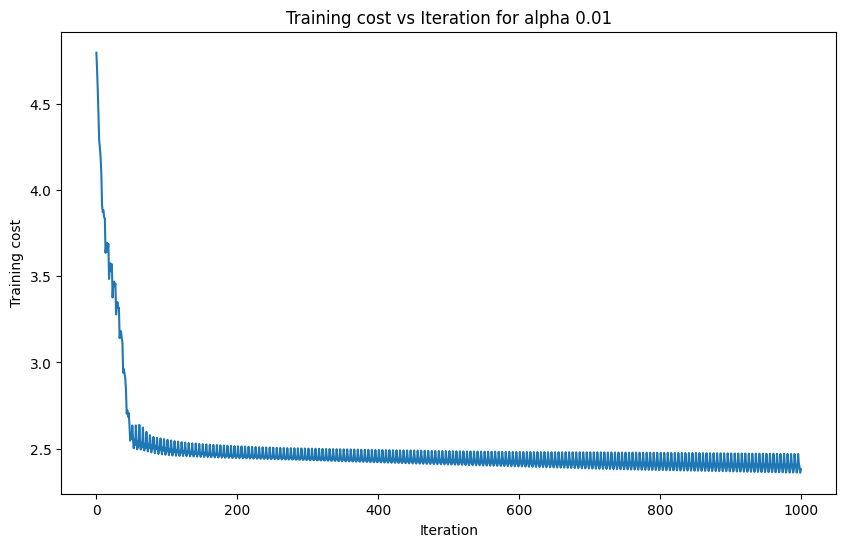

In [49]:
updated_W1, updated_b1, updated_W2, updated_b2, Js = adam_optimizer(
    X=X_train_scaled, 
    Y=Y_train, 
    W1=initial_W1, 
    b1=initial_B1, 
    W2=initial_W2,
    b2=initial_B2,
    lambd=lambd,
    beta_m=beta_m,
    beta_r=beta_r,
    alpha=alpha,
    batch_size=batch_size,
    num_epochs=200
)

iterations = [J[0] for J in Js]
costs = [J[1] for J in Js]

plt.figure(figsize=(10, 6))
plt.plot(iterations, costs)
plt.xlabel("Iteration")
plt.ylabel("Training cost")
plt.title(f"Training cost vs Iteration for alpha {alpha}")

# Evaluate Model

The code below evaluates the performance of the model

In [50]:
def interpret_probabilities(prob):
    """ 
    Function to interpret the returned probabilities by the model
    
    Args:
        prob (ndarray) - array with probabilities for different match results
        
    Returns:
        scores (str) - human readable version of prediction
    """
    predicted = np.argmax(prob)
    home_score = math.floor(predicted / 11)
    away_score = predicted % 11
    return f"{home_score}-{away_score}"

def score_to_index(score: str):
    """ 
    This function takes string representation of score and converts it to index in class list
    
    Args:
        score (scalar): string representation of score e.g. 1-0
        
    Returns:
        index (scalar): index of that score in class list e.g. 11 for 1-0
    """
    scores = score.split('-')
    assert len(scores) == 2, "Invalid score"
    
    home_score = int(scores[0])
    away_score = int(scores[1])
    
    return (home_score * 11) + away_score

score_to_index('1-0')

11

In [51]:
def accuracy_score(y_pred, y_label):
    """ 
    Return the ratio of correct responses across the entire test set.add
    
    Args:
        y_pred (ndarray): (121, m) array with predictions for each class from the model from the model
        y_label(ndarray): (121, m) array with the actual labels
        
    Returns:
        accuracy (scalar): ratio of correct responses to all responses
    """
    predictions = np.argmax(y_pred, axis=0)
    actual = np.argmax(y_label, axis=0)
    num_correct = np.sum(predictions == actual)
    return num_correct / y_pred.shape[1]

In [52]:
class PredictionRecall:
    def __init__(self, t_p: int, f_p: int, f_n:int, total: int, label: str):
        """ 
        Return object with prediction recall values
        
        Args:
            label (str): Name of the class
            t_p (int): Total true positive for the given label
            f_p (int): Total false positives for given label
            total (int): Total items with given label
            f_n (int): Total false negatives for given label
        """
        self.total = total
        self.t_p = t_p
        self.f_p = f_p
        self.f_n = f_n
        self.label = label
        
    def __repr__(self):
        return f"{self.label} with t_p: {self.t_p}, f_p: {self.f_p}, f_n: {self.f_n} and total: {self.total}"

def get_precision_recall(y_pred, y_label) -> list[PredictionRecall]:
    """ 
    Returns the precision and recall of the model based on the predictions it has made
    
    Args:
        y_pred (ndarray) - a (121, m) array with the predictions of the model
        y_label (ndarray) - a (121, m) array with the actual values
        
    Returns:
        prediction_recall (list) - list of prediction recall values
    """
    m = y_label.shape[1]
    
    predictions = [interpret_probabilities(y_pred[:, i]) for i in range(m)]
    actual = [interpret_probabilities(y_label[:, i]) for i in range(m)]
    all_items = predictions.copy()
    all_items.extend(actual)
    labels = set(all_items)

    precisions = []
    
    for label in labels:
        total = 0
        false_positive = 0
        false_negative = 0
        true_positive = 0
        
        for i in range(m):
            entry = actual[i]
            pred = predictions[i]
            
            if entry == label:
                total += 1
                
            if entry == label and pred == entry:
                true_positive += 1
            elif entry != label and pred == label:
                false_positive += 1
        false_negative = total - true_positive
        
        precisions.append(PredictionRecall(
            t_p=true_positive,
            f_p=false_positive,
            f_n=false_negative,
            total=total,
            label=label
        ))
    
    return precisions
    
def precision_recall(y_pred, y_label):
    """ 
        Print precision recall for model predictions
        
        Args:
            y_pred (ndarray): a (m, 121, 1) array with the predictions of the model
            y_label (ndarray): a (m, 121, 1) array with labels of the model
    """ 
    precisions = get_precision_recall(y_pred=y_pred, y_label=y_label)
    
    # Order precisions by totals
    n = len(precisions)
    for i in range(n):
        swapped = False
        
        for j in range(0, n-i-1):
            # Traverse array from 0 to n - i - 1
            # Swap if the element found is lesser than next element
            if precisions[j].total < precisions[j+1].total:
                precisions[j], precisions[j + 1] = precisions[j + 1], precisions[j]
                swapped = True
        
        if (swapped == False):
            break
    
    
    print(f"    Precision and recall")
    for prec in precisions:
        precision = 0 if prec.f_p + prec.t_p == 0 else (prec.t_p / (prec.f_p + prec.t_p))
        recall = 0 if prec.t_p + prec.f_n == 0 else (prec.t_p) / (prec.t_p + prec.f_n)
        p_1 = 0 if precision == 0 else 1 / precision
        r_1 = 0 if recall == 0 else 1 / recall
        f1_score = 1 / 0.5 * (p_1 + r_1)
        n_predictions = prec.t_p + prec.f_p
        print(f"{prec.label.center(5)}  TP:{prec.t_p}  FP:{prec.f_p}  FN:{prec.f_n}: Prec:{precision:.4f}  Rec:{recall:.4f}  F1:{f1_score:.4f}  #Pred: {n_predictions}  Sample:{prec.total}")

In [53]:
def win_prediction_accuracy(y_pred, y_label):
    """ 
    Returns the ratio of accuratey predicted win / loss outcomes
    
    Args:
        y_pred (ndarray) - a (121, m) with model's predictions
        y_label (ndarray) - a (121, m) with actual labels
        
    Returns
        win_loss_accuracy (scalar) - ratio of correctly predicted wins / losses
    """
    win = 0
    draw = 1
    loss = 2
    
    predictions = np.argmax(y_pred, axis=0)
    predicted_wins = []
    actual = np.argmax(y_label, axis=0)
    actual_wins = []
    m = len(actual)
    
    for i in range(m):
        predicted_outcome = predictions[i]
        predicted_home = math.floor(predicted_outcome / 11)
        predicted_away = predicted_outcome % 11
        predicted_label = win if predicted_home > predicted_away else draw if predicted_home == predicted_away else loss
        predicted_wins.append(predicted_label)
        
        actual_outcome = actual[i]
        actual_home = math.floor(actual_outcome / 11)
        actual_away = actual_outcome % 11
        actual_label = win if actual_home > actual_away else draw if actual_home == actual_away else loss
        actual_wins.append(actual_label)
    
    return sum([predicted_wins[i] == actual_wins[i] for i in range(m)]) / m

In [54]:
# Checking if model has high bias, high variance or has reached benchmarks
train_set_pred, _, _ = f_x(X=X_train_scaled, W1=updated_W1, b1=updated_b1, W2=updated_W2, b2=updated_b2)
cv_set_pred, _, _ = f_x(X=X_cv_scaled, W1=updated_W1, b1=updated_b1, W2=updated_W2, b2=updated_b2)

training_set_accuracy = accuracy_score(train_set_pred, Y_train)
cv_set_accuracy = accuracy_score(cv_set_pred, Y_cv)
training_set_win_pred_accuracy = win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
cv_set_win_pred_accuracy = win_prediction_accuracy(y_pred=cv_set_pred, y_label=Y_cv)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"CV Set Score Accuracy   : {cv_set_accuracy}")
print(f"CV Set Win Accuracy     : {cv_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.18703241895261846
Training Win Accuracy   : 0.5037406483790524
CV Set Score Accuracy   : 0.11224489795918367
CV Set Win Accuracy     : 0.45918367346938777


In [55]:
precision_recall(y_pred=cv_set_pred, y_label=Y_cv)

    Precision and recall
 1-0   TP:0  FP:3  FN:11: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 3  Sample:11
 3-0   TP:2  FP:26  FN:8: Prec:0.0714  Rec:0.2000  F1:38.0000  #Pred: 28  Sample:10
 0-1   TP:0  FP:6  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 6  Sample:10
 0-4   TP:0  FP:0  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:10
 0-2   TP:5  FP:11  FN:5: Prec:0.3125  Rec:0.5000  F1:10.4000  #Pred: 16  Sample:10
 0-3   TP:2  FP:20  FN:6: Prec:0.0909  Rec:0.2500  F1:30.0000  #Pred: 22  Sample:8
 4-0   TP:0  FP:0  FN:8: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:8
 2-0   TP:1  FP:10  FN:7: Prec:0.0909  Rec:0.1250  F1:38.0000  #Pred: 11  Sample:8
 0-5   TP:0  FP:0  FN:7: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:7
 0-0   TP:1  FP:10  FN:5: Prec:0.0909  Rec:0.1667  F1:34.0000  #Pred: 11  Sample:6
 6-0   TP:0  FP:0  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:3
 5-0   TP:0  FP:1  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 1  S

# Error Analysis

I'll analyze the data in classes that had issues and see if I will get any new ideas of model improvements

One of the functions I'll have will accept a class and plot the following:
1. Matches that were predicted correctly (TP) - green
2. Matches that were falsely predicted (FP) - red
3. Matches that were missed (FN) - grey

I think it will also be useful to show a table with the correct labels of each item in the diagram

In [83]:
def get_tp_fp_fn_of_class(
    match_result: str,
    features: npt.NDArray,
    labels: npt.NDArray,
    predictions: npt.NDArray
): 
    """ 
    Function to get true positives, false positives and false negatives based on match result given and model predictions
    
    Args:
        match_result (scalar): Match result that we want to analyze
        features (ndarray): a (9,m) array with m training features that model used to get predictions
        labels (ndarray): a (121, m) array with m actual labels of the provided features
        predictions (ndarray): a (121, m) array with m predicted labels
        
    Returns:
        TP (ndarray): a (9,x) array with x features that were predicted correctly
        FP (ndarray): a (9,y) array with y features that were falsely predicted to have match result
        FN (ndarray): a (9, z) array with z features that were falsely predicted to not have match result
        FP_class_indices (ndarray): a (y,) array with actual class labels for FP
    """
    m = features.shape[1]
    match_result_index = score_to_index(match_result)
    
    TP_indexes = []
    FP_indexes = []
    FN_indexes = []
    FP_class_indices = []
    
    for i in range(m):
        prediction = predictions[: ,i]
        predicted_index = np.argmax(prediction)
       
        actual = labels[:, i]
        actual_indx = np.argmax(actual)
        
        # Get TPs i.e. prediction = label and label == match
        if (predicted_index == actual_indx and actual_indx == match_result_index):
            TP_indexes.append(i)
        # Get FN i.e prediction != label and label == prediction
        elif (predicted_index != actual_indx and actual_indx == match_result_index):
            FN_indexes.append(i)
        # Get FP i.e prediction = match but label != match
        elif (predicted_index == match_result_index and actual_indx != match_result_index):
            FP_indexes.append(i)
            FP_class_indices.append(actual_indx)
            
    TP = features[:, TP_indexes]
    FP = features[:, FP_indexes]
    FN = features[: , FN_indexes]
    FP_class_indices = np.array(FP_class_indices)
    
    return (TP, FP, FN, FP_class_indices)
    
    
TP, FP, FN, FP_class_indices = get_tp_fp_fn_of_class(match_result='3-0', features=X_cv_scaled, labels=Y_cv, predictions=cv_set_pred)
print(TP.shape, FP.shape, FN.shape, FP_class_indices.shape)

(9, 2) (9, 26) (9, 8) (26,)


1.0


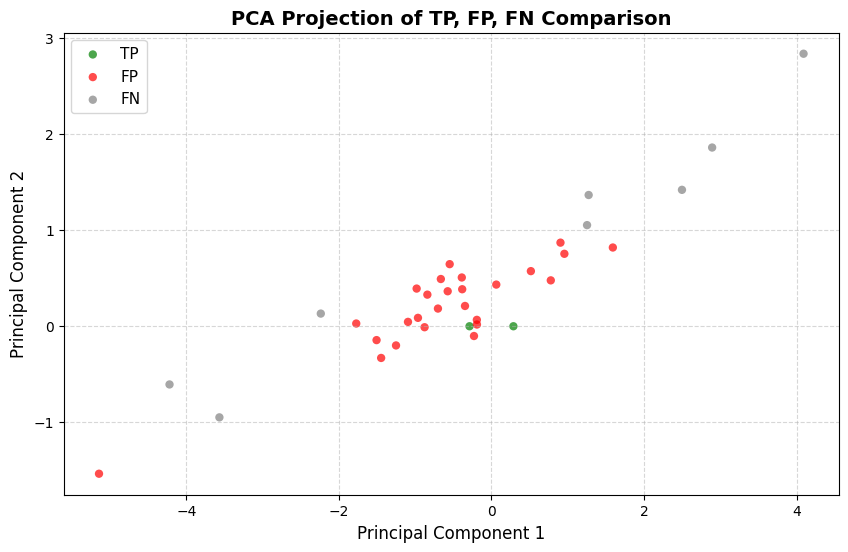

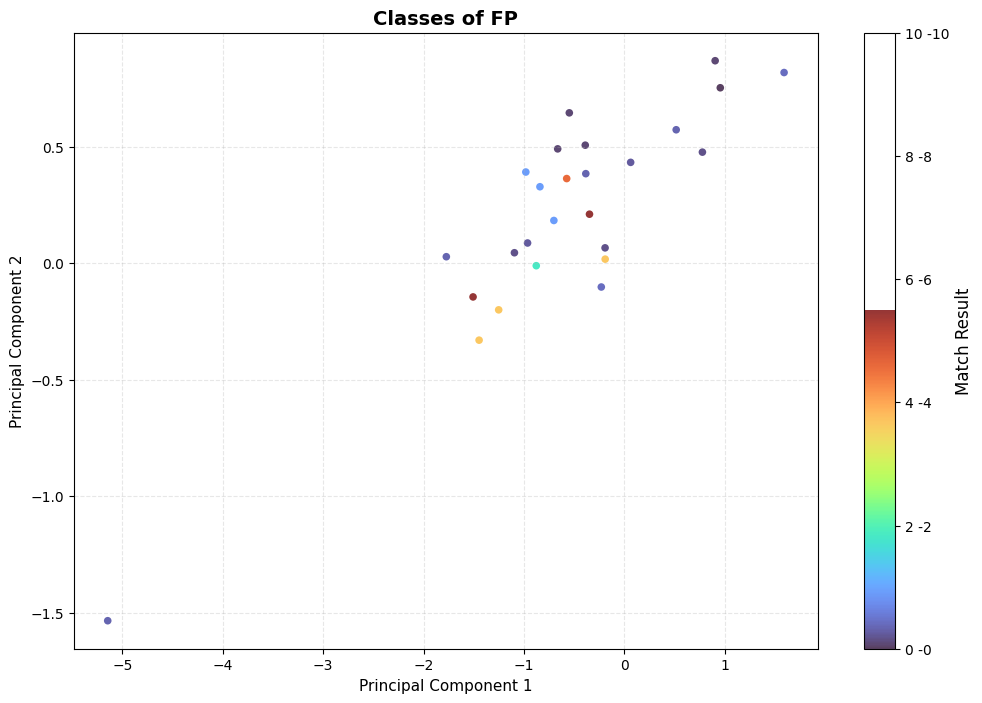

Tag PCA          Actual
TP [-2.88e-01 -1.11e-16]  [-3.24e-02 -5.81e-04 -3.03e-03 -5.48e-03 -3.03e-03 -1.77e-02  1.44e-01
  7.00e-01 -1.52e-03]
TP [0.29 0.  ]  [ 3.86e-02  4.32e-03 -7.93e-03 -5.81e-04 -3.03e-03  1.87e-03  5.65e-01
  1.08e+00 -1.61e-02]
FP [0.78 0.48]  [ 2.64e-02 -5.81e-04  4.32e-03 -1.04e-02 -3.03e-03  4.32e-03  1.44e+00
  8.59e-01  3.37e-02]
FP [-1.51 -0.14]  [-0.01  0.   -0.01 -0.   -0.   -0.01 -1.02  0.15 -0.01]
FP [-5.15 -1.54]  [-6.67e-02  6.77e-03 -5.48e-03 -3.03e-03 -3.03e-03  1.66e-02 -5.34e+00
 -5.47e-01  1.39e-01]
FP [-0.96  0.09]  [-0.01 -0.01 -0.01  0.   -0.   -0.01 -0.36  0.23 -0.02]
FP [0.96 0.75]  [ 5.08e-02 -3.03e-03 -5.81e-04 -7.93e-03 -3.03e-03 -3.03e-03  1.84e+00
  6.88e-01 -1.52e-02]
FP [-0.35  0.21]  [ 0.03  0.    0.   -0.01 -0.   -0.01  0.25  0.48  0.  ]
FP [-0.88 -0.01]  [-0.03 -0.   -0.   -0.   -0.    0.01 -0.36  0.37  0.01]
FP [0.9  0.87]  [-0.05 -0.01  0.   -0.01 -0.   -0.01  1.99  0.47  0.01]
FP [-0.84  0.33]  [-0.04 -0.   -0.01 -0.   -0.    0

In [84]:
def plot_values(
    TP: npt.NDArray,
    FP: npt.NDArray,
    FN: npt.NDArray,
    FP_class_indices: npt.NDArray
):
    """ 
    Plot TP, FP and FN on a scatter plot to see if they're related. PCA compression will be used to reduce space to 2 dimensions
    
    Args:
        TP (ndarray): a (9, x) array with x TP values - green
        FP (ndarray): a (9, y) array with y FP values - red
        FN (ndarray): a (9, z) array with z FN values - gray
    """
    # PCA expects last value in shape to be number of features, that is not the case in my dataset so I need to transpose
    TP = TP.T
    FP = FP.T
    FN = FN.T
    
    TP_has_content = TP.shape[0] > 0
    FP_has_content = FP.shape[0] > 0
    FN_has_content = FN.shape[0] > 0
    
    pca = PCA(n_components=2)
    if TP_has_content:
        pca.fit(TP)
    elif FP_has_content:
        pca.fit(FP)
    elif FN_has_content:
        pca.fit(FN)
    else:
        raise Exception("No data in TP, FP or FN")
    
    print(np.sum(pca.explained_variance_ratio_))
    
    TP_compressed = pca.transform(TP) if TP_has_content else []
    FP_compressed = pca.transform(FP) if FP_has_content else []
    FN_compressed = pca.transform(FN) if FN_has_content else []

    plt.figure(figsize=(10, 6))
    if TP_has_content: plt.scatter(TP_compressed[:, 0], TP_compressed[:, 1], color='green', label='TP', alpha=0.7, edgecolors='none')
    if FP_has_content: plt.scatter(FP_compressed[:, 0], FP_compressed[:, 1], color='red', label='FP', alpha=0.7, edgecolors='none')
    if FN_has_content: plt.scatter(FN_compressed[:, 0], FN_compressed[:, 1], color='grey', label='FN', alpha=0.7, edgecolors='none')
    
    plt.title('PCA Projection of TP, FP, FN Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best', fontsize=11)  # Automatically maps colors to labels

    plt.show()
    
    # For FP indexes I want to show what the actual is
    if FP_has_content:
        label_lookup = [f"{math.floor(i / 11)} -{i%11}" for i in range(121)]
        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(
            FP_compressed[:, 0], 
            FP_compressed[:, 1], 
            c=FP_class_indices, 
            cmap='turbo', 
            alpha=0.8, 
            edgecolors='none',
            s=30
        )
        cbar = plt.colorbar(scatter, ticks=np.linspace(0, 120, 11))
        cbar.set_label('Match Result', fontsize=12)
        
        tick_positions = np.linspace(0, 120, 6, dtype=int)
        cbar.set_ticks(tick_positions)
        cbar.set_ticklabels([label_lookup[idx] for idx in tick_positions])
        
        plt.title('Classes of FP', fontsize=14, fontweight='bold')
        plt.xlabel('Principal Component 1', fontsize=11)
        plt.ylabel('Principal Component 2', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.3)

        plt.show()
    
    # Show table with breakdown of PCA compressed and actual
    print("Tag PCA          Actual")
    
    # TP
    for i in range(len(TP_compressed)):
        with np.printoptions(precision=2):
            print(f"TP {TP_compressed[i, :]}  {TP[i, :]}")
        
    # FP
    for i in range(len(FP_compressed)):
        with np.printoptions(precision=2):
            print(f"FP {FP_compressed[i, :]}  {FP[i, :]}")
        
    # FN
    for i in range(len(FN_compressed)):
        with np.printoptions(precision=2):
            print(f"FN {FN_compressed[i, :]}  {FN[i, :]}")
    
plot_values(TP=TP, FP=FP, FN=FN, FP_class_indices=FP_class_indices)